# 02 — Mathematical Primer
**Goal:** Review the three pieces of math used in every chapter: linear
algebra, probability, and optimization. Sources: ISLR Appendix, Goodfellow
Ch2-4, Bishop Ch1-2, Murphy Ch2-3.

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/learning_courses')

import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

## 1. Why this chapter exists

You can call `sklearn.linear_model.LogisticRegression().fit(X, y)` and get a
trained model without knowing any math. But you cannot:

- explain *why* the coefficients are what they are,
- debug a case where the model fails,
- read a paper and understand what the authors did,
- choose between two models for a new problem.

This notebook is the minimum math that closes the gap between *running* ML
and *understanding* it. If you have a strong math background, skim it.

## 2. Linear algebra

### Notation
  - x ∈ ℝⁿ — column vector of n reals
  - X ∈ ℝⁿˣᵈ — matrix of n rows (examples) and d columns (features)
  - X⁺ — Moore-Penrose pseudoinverse
  - ‖x‖₂ = √(Σ xᵢ²) — Euclidean norm
  - x ⊤ y = Σ xᵢyᵢ — dot product

### The four operations you must know
  - Matrix-vector product:  Ax = b
  - Matrix-matrix product:  AB
  - Transpose:              (AB)⊤ = B⊤A⊤
  - Inverse (if it exists): A A⁻¹ = I

In [2]:
A = np.array([[1, 2], [3, 4], [5, 6]])     # 3 x 2
x = np.array([1, 10])                     # 2
b = A @ x                                  # 3
print('A  :\n', A)
print('x  :', x)
print('A@x:', b)
print('A.T shape:', A.T.shape)

A  :
 [[1 2]
 [3 4]
 [5 6]]
x  : [ 1 10]
A@x: [21 43 65]
A.T shape: (2, 3)


### The one fact that powers linear regression

If X ∈ ℝⁿˣᵈ has full column rank, the unique minimizer of
‖Xβ − y‖² is

```
β̂ = (X⊤X)⁻¹ X⊤ y      (normal equation)
    = X⁺ y              (pseudoinverse form)
```

When d > n (more features than examples) X⊤X is singular and the normal
equation breaks — that is the entire motivation for **regularization**
(notebook 08) and for **gradient descent** (notebook 02 §6).

In [3]:
np.random.seed(0)
n, d = 50, 3
X = np.random.randn(n, d)
beta_true = np.array([1, -2, 0.5])
y = X @ beta_true + 0.1 * np.random.randn(n)
beta_hat = np.linalg.inv(X.T @ X) @ X.T @ y
print('true :', beta_true)
print('fit  :', np.round(beta_hat, 3))

true : [ 1.  -2.   0.5]
fit  : [ 0.989 -2.011  0.49 ]


## 3. Probability

### The four distributions you must recognize

| Distribution | Density / PMF | Used for |
|---|---|---|
| **Bernoulli(p)** | pˣ(1-p)¹⁻ˣ | coin flip, binary classification |
| **Categorical(p)** | Π pᵢ^yᵢ | multi-class classification (softmax) |
| **Gaussian(μ, σ²)** | (2πσ²)^(-1/2) exp(-(x-μ)²/2σ²) | regression noise, prior |
| **Multivariate Gaussian(μ, Σ)** | ... | joint distribution of features |

### The two theorems that show up everywhere

**Law of large numbers:** as n → ∞, the sample mean x̄ → 𝔼[X].

**Central limit theorem:** as n → ∞, √n(x̄ − μ) → N(0, σ²). The sample mean
is approximately normal, *regardless of the underlying distribution*.

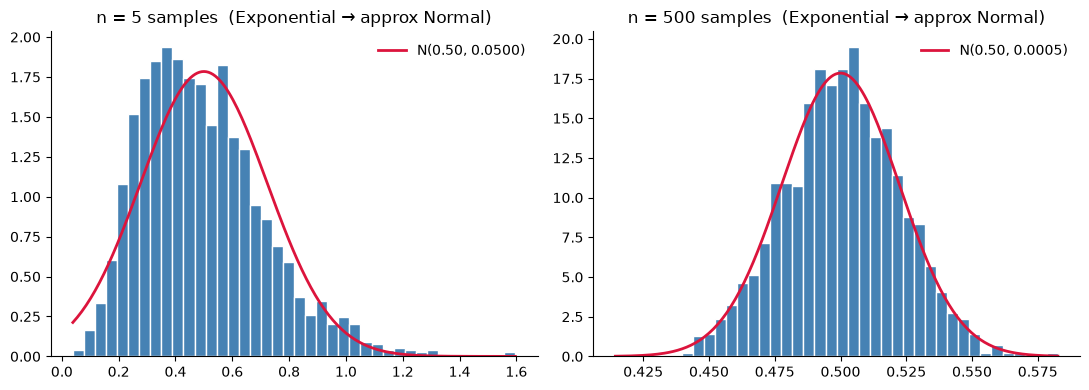

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
lam = 2.0
for ax, n in zip(axes, [5, 500]):
    means = np.array([np.mean(np.random.exponential(1/lam, n)) for _ in range(2000)])
    ax.hist(means, bins=40, color='steelblue', edgecolor='white', density=True)
    xs = np.linspace(means.min(), means.max(), 200)
    sigma = (1/lam) / np.sqrt(n)
    ax.plot(xs, np.exp(-(xs - 1/lam)**2 / (2*sigma**2)) / np.sqrt(2*np.pi*sigma**2),
            color='crimson', lw=2, label=f'N({1/lam:.2f}, {(1/lam/np.sqrt(n))**2:.4f})')
    ax.set_title(f'n = {n} samples  (Exponential → approx Normal)')
    ax.legend(frameon=False)
    ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

### Conditional probability and Bayes' rule

```
P(A | B) = P(B | A) P(A) / P(B)

posterior  ∝  likelihood × prior
```

Every probabilistic model is some version of this. Logistic regression is
discriminative (models P(y|x) directly); naive Bayes is generative (models
P(x|y) and P(y) and applies Bayes' rule). LDA and Gaussian process
regression are also generative.

In [5]:
# Bayes' rule, illustrated: medical test with 1% prevalence, 95% sensitivity, 90% specificity
P_D    = 0.01
P_posD = 0.95
P_negN = 0.90
P_pos  = P_posD * P_D + (1 - P_negN) * (1 - P_D)
P_Dpos = P_posD * P_D / P_pos
print(f'P(disease | positive test) = {P_Dpos:.3f}   <- the surprise)')
print('Even with a 95%%-sensitive test, most positives are false positives at 1%% prevalence.')

P(disease | positive test) = 0.088   <- the surprise)
Even with a 95%%-sensitive test, most positives are false positives at 1%% prevalence.


## 4. Calculus — gradients and Jacobians

A scalar function f : ℝᵈ → ℝ has a gradient ∇f ∈ ℝᵈ:

```
∇f = [∂f/∂x₁, ∂f/∂x₂, ..., ∂f/∂x_d]⊤
```

Gradient points uphill; negative gradient points downhill. Gradient descent
follows the negative gradient to minimize f.

A vector-valued function f : ℝᵈ → ℝᵐ has a Jacobian J ∈ ℝᵐˣᵈ where
Jᵢⱼ = ∂fᵢ/∂xⱼ.

In [6]:
import sympy as sp
x1, x2 = sp.symbols('x1 x2')
f = 3*x1**2 + 2*x1*x2 + x2**2 - 4*x1 + 5
print('f(x1, x2) =', f)
print('∇f        =', [sp.diff(f, v) for v in (x1, x2)])

f(x1, x2) = 3*x1**2 + 2*x1*x2 - 4*x1 + x2**2 + 5
∇f        = [6*x1 + 2*x2 - 4, 2*x1 + 2*x2]


## 5. Optimization — gradient descent

**Problem:** minimize f(θ) over θ ∈ ℝᵈ.

**Algorithm:**
```
θ_{t+1} = θ_t - η_t ∇f(θ_t)
```
where η_t is the learning rate.

Properties:
- Converges for convex f with appropriate η (e.g. η = 1/L for f L-smooth).
- For non-convex f, converges to a *local* minimum. Multiple restarts are
  the practical workaround.
- Stochastic gradient descent (SGD) replaces ∇f with the gradient of a
  mini-batch loss; this is what trains every neural network.

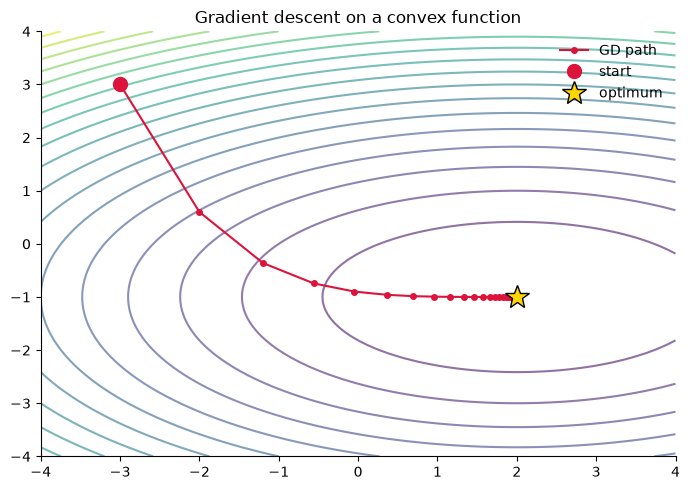

In [7]:
def gradient_descent(f, grad_f, theta0, eta=0.1, n_iter=50):
    theta = theta0.copy()
    path = [theta.copy()]
    for _ in range(n_iter):
        theta = theta - eta * grad_f(theta)
        path.append(theta.copy())
    return np.array(path)

f      = lambda t: (t[0] - 2)**2 + 3*(t[1] + 1)**2
grad_f = lambda t: np.array([2*(t[0]-2), 6*(t[1]+1)])
path   = gradient_descent(f, grad_f, np.array([-3.0, 3.0]), eta=0.1, n_iter=40)

fig, ax = plt.subplots(figsize=(7, 5))
T1, T2 = np.meshgrid(np.linspace(-4, 4, 100), np.linspace(-4, 4, 100))
F = (T1 - 2)**2 + 3*(T2 + 1)**2
ax.contour(T1, T2, F, levels=20, cmap='viridis', alpha=0.6)
ax.plot(path[:, 0], path[:, 1], 'o-', color='crimson', lw=1.5, markersize=4, label='GD path')
ax.plot(*path[0], 'o', color='crimson', markersize=10, label='start')
ax.plot(2, -1, '*', color='gold', markersize=18, markeredgecolor='black', label='optimum')
ax.legend(frameon=False)
ax.set_title('Gradient descent on a convex function')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 6. Information theory — entropy and KL

Two more concepts that show up constantly.

**Entropy** of a distribution p:
  H(p) = -Σ p(x) log p(x)    (in nats; multiply by log 2 for bits)

**Cross-entropy** between true p and predicted q:
  H(p, q) = -Σ p(x) log q(x)

**KL divergence** = H(p, q) - H(p) ≥ 0, with equality iff p = q.

**Logistic regression loss** is the cross-entropy between the true label and
the predicted probability. **MSE** is the negative log-likelihood under a
Gaussian noise model. **Every loss function is a log-likelihood in disguise**.

In [8]:
def entropy(p):
    p = np.asarray(p)
    p = p[p > 0]
    return -np.sum(p * np.log(p))

print(f'H([0.5, 0.5])   = {entropy([0.5, 0.5]):.3f} nats   (max entropy)')
print(f'H([0.9, 0.1])   = {entropy([0.9, 0.1]):.3f} nats')
print(f'H([1.0, 0.0])   = {entropy([1.0, 0.0]):.3f} nats   (min entropy)')
print()
p = np.array([0.5, 0.5])
for q in [[0.5, 0.5], [0.7, 0.3], [0.99, 0.01], [0.0, 1.0]]:
    q = np.array(q) + 1e-12
    H_pq = -np.sum(p * np.log(q))
    print(f'cross-entropy H(p, q={q.round(2).tolist()}) = {H_pq:.3f}')

H([0.5, 0.5])   = 0.693 nats   (max entropy)
H([0.9, 0.1])   = 0.325 nats
H([1.0, 0.0])   = -0.000 nats   (min entropy)

cross-entropy H(p, q=[0.5, 0.5]) = 0.693
cross-entropy H(p, q=[0.7, 0.3]) = 0.780
cross-entropy H(p, q=[0.99, 0.01]) = 2.308
cross-entropy H(p, q=[0.0, 1.0]) = 13.816


## 7. A worked example — the cross-entropy loss in 8 lines

The logistic regression loss for one example (label y ∈ {0, 1}, predicted p ∈
(0, 1)) is

    ℓ(y, p) = -[y log p + (1 - y) log(1 - p)]

The gradient with respect to the linear score z = w⊤x + b is

    ∂ℓ / ∂z = p - y.

That is the entire backprop story for logistic regression.

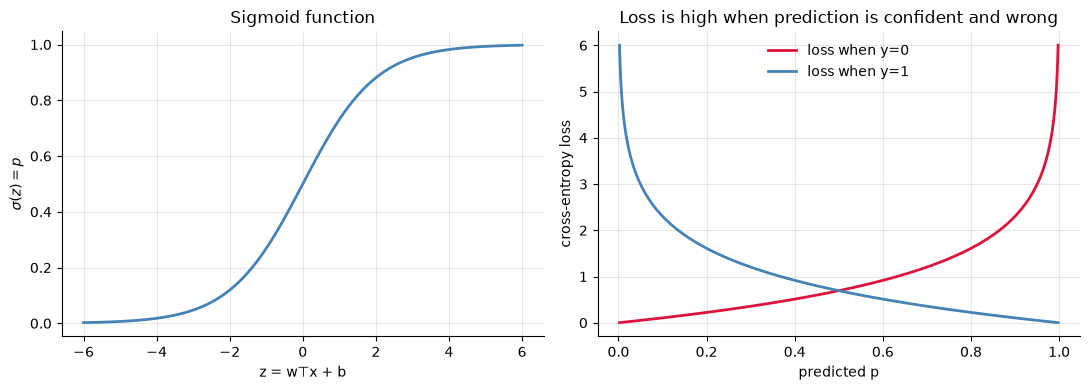

In [9]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def ce_loss(y, p):
    p = np.clip(p, 1e-12, 1 - 1e-12)
    return -(y * np.log(p) + (1 - y) * np.log(1 - p))

z = np.linspace(-6, 6, 100)
p = sigmoid(z)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(z, p, color='steelblue', lw=2)
axes[0].set_xlabel('z = w\u22a4x + b'); axes[0].set_ylabel(r'$\sigma(z) = p$')
axes[0].set_title('Sigmoid function')
axes[0].spines[['top','right']].set_visible(False)
axes[0].grid(alpha=0.3)

axes[1].plot(p, ce_loss(0, p), label='loss when y=0', color='crimson', lw=2)
axes[1].plot(p, ce_loss(1, p), label='loss when y=1', color='steelblue', lw=2)
axes[1].set_xlabel('predicted p'); axes[1].set_ylabel('cross-entropy loss')
axes[1].set_title('Loss is high when prediction is confident and wrong')
axes[1].legend(frameon=False)
axes[1].spines[['top','right']].set_visible(False)
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 8. The one-paragraph summary

Every supervised model can be written as three pieces:
1. A **model class** f(x; θ) parameterized by θ ∈ ℝᵈ (linear, tree, network).
2. A **loss function** ℓ(y, f(x; θ)) that scores a single prediction (squared
   error, cross-entropy, hinge).
3. An **optimizer** that finds θ that minimizes the empirical loss on the
   training data (closed form, gradient descent, second-order methods).

Notebooks 05-13 of this course are organized exactly along these three axes.

## Summary

| Topic | Key formula |
|---|---|
| Linear algebra | β̂ = (X⊤X)⁻¹ X⊤y |
| Bayes' rule | P(A|B) = P(B|A)P(A) / P(B) |
| LLN / CLT | x̄ → μ, √n(x̄ - μ) → N(0, σ²) |
| Gradient descent | θ ← θ - η ∇f(θ) |
| Cross-entropy | H(p, q) = -Σ p log q |
| Logistic loss | ℓ(y, p) = -[y log p + (1-y) log(1-p)] |

**Next:** `03_statistical_learning_framework.ipynb` — the language of
supervised learning.